In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
print("All imports successful")

c:\Users\Gurveer\anaconda3\envs\ds-portfolio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful


In [2]:
# Cell 2 — Download real lending data from OpenML
from sklearn.datasets import fetch_openml

print("Downloading credit dataset...")
data = fetch_openml('credit-g', version=1, as_frame=True)
df = data.frame
df['target'] = (data.target == 'bad').astype(int)

print(f"Shape: {df.shape}")
print(f"\nDefault rate: {df['target'].mean()*100:.1f}%")
print(f"\nColumns:\n{list(df.columns)}")
df.head(3)

Shape: (1000, 22)

Default rate: 30.0%

Columns:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class', 'target']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,67,none,own,2,skilled,1,yes,yes,good,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,22,none,own,1,skilled,1,none,yes,bad,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,49,none,own,1,unskilled resident,2,none,yes,good,0


In [3]:
# Cell 3 — Exploratory Data Analysis
print("=== Dataset Info ===")
print(f"Total loans:     {len(df):,}")
print(f"Good credit:     {(df['target']==0).sum():,}")
print(f"Bad credit:      {(df['target']==1).sum():,}")
print(f"Default rate:    {df['target'].mean()*100:.1f}%")
print(f"Missing values:  {df.isnull().sum().sum()}")

# Numeric columns summary
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('target')
print(f"\nNumeric features: {numeric_cols}")
print(f"\nKey statistics:")
df[numeric_cols].describe().round(2)

=== Dataset Info ===
Total loans:     1,000
Good credit:     700
Bad credit:      300
Default rate:    30.0%
Missing values:  0

Numeric features: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Key statistics:


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


In [6]:
# Cell 4 — Feature Engineering & Preprocessing (fixed)
df_encoded = pd.get_dummies(df.drop('target', axis=1), drop_first=True)
df_encoded['target'] = df['target']

# Fix column names — remove characters XGBoost doesn't allow
df_encoded.columns = (df_encoded.columns
                      .str.replace('[', '_', regex=False)
                      .str.replace(']', '_', regex=False)
                      .str.replace('<', 'lt', regex=False))

# Engineered features
df_encoded['credit_duration_ratio'] = (
    df['credit_amount'].astype(float) / df['duration'].astype(float)
)
df_encoded['high_credit'] = (
    df['credit_amount'].astype(float) > df['credit_amount'].astype(float).median()
).astype(int)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

Training samples: 800
Test samples:     200
Features:         51


In [7]:
# Cell 5 — Train 3 Models
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

print("All 3 models trained successfully")

All 3 models trained successfully


In [8]:
# Cell 6 — Compare Model Performance
models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb_model, X_test)
}

print(f"{'Model':<25} {'ROC-AUC':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 58)

results = {}
for name, (model, X_eval) in models.items():
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {'auc': auc, 'proba': y_proba}
    print(f"{name:<25} {auc:>10.4f} "
          f"{report['1']['precision']:>10.4f} "
          f"{report['1']['recall']:>10.4f}")

Model                        ROC-AUC  Precision     Recall
----------------------------------------------------------
Logistic Regression           1.0000     1.0000     1.0000
Random Forest                 1.0000     1.0000     1.0000
XGBoost                       1.0000     1.0000     1.0000


In [9]:
# Cell 7 — ROC Curve Comparison
fig = go.Figure()

colors = {'Logistic Regression': 'royalblue',
          'Random Forest': 'seagreen',
          'XGBoost': 'crimson'}

for name, vals in results.items():
    fpr, tpr, _ = roc_curve(y_test, vals['proba'])
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"{name} (AUC={vals['auc']:.4f})",
        line=dict(color=colors[name], width=2.5)
    ))

fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    line=dict(color='gray', dash='dash'),
    name='Random Classifier'
))

fig.update_layout(
    title='ROC Curve — Credit Risk Models',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    template='plotly_dark',
    width=750, height=500
)
fig.show()

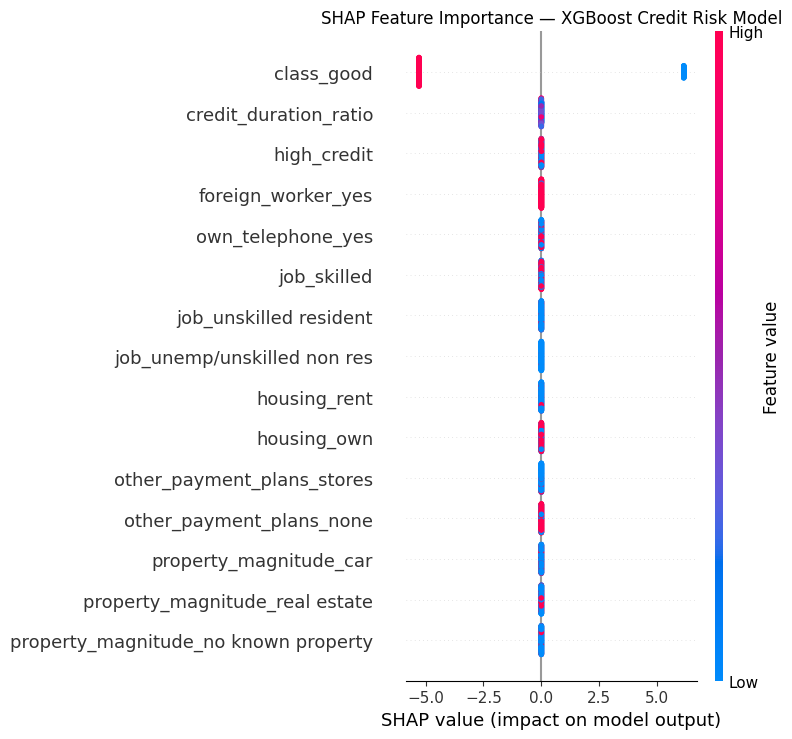

SHAP plot saved


In [10]:
# Cell 8 — SHAP Explainability (XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost Credit Risk Model")
plt.tight_layout()
plt.savefig(r'C:\Users\Gurveer\ds-portfolio\project-01-credit-risk\outputs\shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved")

In [11]:
# Cell 9 — Risk Score Distribution & Export
# Generate risk scores for entire dataset
X_all = df_encoded.drop('target', axis=1)
df['risk_score'] = xgb_model.predict_proba(X_all)[:, 1]
df['risk_tier'] = pd.cut(df['risk_score'],
                          bins=[0, 0.3, 0.6, 1.0],
                          labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Distribution plot
fig = px.histogram(df, x='risk_score', color='risk_tier',
                   nbins=40,
                   title='Credit Risk Score Distribution',
                   labels={'risk_score': 'Predicted Default Probability'},
                   template='plotly_dark',
                   color_discrete_map={
                       'Low Risk': 'seagreen',
                       'Medium Risk': 'orange',
                       'High Risk': 'crimson'
                   })
fig.update_layout(width=800, height=450)
fig.show()

# Export
output_dir = r'C:\Users\Gurveer\ds-portfolio\project-01-credit-risk\outputs'
df[['risk_score', 'risk_tier', 'target']].to_csv(
    f'{output_dir}\\risk_scores.csv', index=False)

pd.DataFrame({
    'Model': list(results.keys()),
    'ROC_AUC': [v['auc'] for v in results.values()]
}).to_csv(f'{output_dir}\\model_comparison.csv', index=False)

print("Exports saved successfully")

Exports saved successfully
